<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/Project/1_dop_Identification_Rate_Metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Доп. задание 1. Метрика Identification Rate (TPR@FPR)

Accuracy измеряет качество на знакомых личностях, но ничего не говорит о работе на людях, которых
не было в обучении — а это главный сценарий для распознавания лиц. Для этого используют метрику
TPR@FPR (identification rate).

Идея: берём два набора лиц, которых сеть не видела, — query (несколько личностей по несколько фото)
и distractors (много посторонних лиц). Дальше:

1. считаем косинусные сходства пар «один человек» внутри query (positive);
2. считаем сходства пар «разные люди» внутри query (negative);
3. считаем сходства всех пар query×distractors (тоже negative);
4. false-пары = (2) + (3);
5. фиксируем FPR (например 0.01), это задаёт допустимое число ложных срабатываний `N = FPR * (число false-пар)`;
6. сортируем сходства false-пар по убыванию, берём N-е значение — это порог;
7. TPR = доля positive-пар со сходством выше порога.

Смысл: при заданной вероятности «принять чужого за своего» (FPR) смотрим, какую долю «своих» пар
сеть уверенно опознаёт (TPR). Записывают как TPR@FPR=0.01.

## 0. query и distractors

Личности для query и distractors я отложил ещё в Задании 1 (папки `aligned/query` и
`aligned/distractors`) — они не участвовали в обучении, поэтому метрика честная. Размеры наборов
ограничиваю: число пар на шагах 1–3 растёт квадратично.

In [ ]:
import os, glob, math
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
import cv2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = "/content/drive/MyDrive/face_project"
ALIGNED_DIR = os.path.join(WORK_DIR, "aligned")
EMB_DIM, IMG_SIZE = 512, 112
MEAN = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
STD  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

# --- Монтирование Google Drive (безопасно к повторному запуску) ---
import shutil
try:
    from google.colab import drive
    if os.path.ismount('/content/drive'):
        print('Google Drive уже смонтирован.')
    else:
        if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
            shutil.rmtree('/content/drive', ignore_errors=True)
        drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Не Colab-окружение — монтирование Drive пропущено.')

def build_query_distractors(query_dir, distr_dir, max_query_ids=40, max_imgs_per_id=10,
                            max_distractors=600):
    query_dict, query_img_names = {}, []
    for d in sorted(glob.glob(os.path.join(query_dir, "*")))[:max_query_ids]:
        imgs = sorted(glob.glob(os.path.join(d, "*")))[:max_imgs_per_id]
        if len(imgs) >= 2:                       # для positive-пар нужно >= 2 фото
            query_dict[int(os.path.basename(d))] = imgs
            query_img_names += imgs
    distractors = []
    for d in sorted(glob.glob(os.path.join(distr_dir, "*"))):
        distractors += sorted(glob.glob(os.path.join(d, "*")))
    return query_dict, query_img_names, distractors[:max_distractors]

query_dict, query_img_names, distractors_img_names = build_query_distractors(
    os.path.join(ALIGNED_DIR, "query"), os.path.join(ALIGNED_DIR, "distractors"))
print("query: личностей =", len(query_dict), "| фото =", len(query_img_names))
print("distractors: фото =", len(distractors_img_names))

Mounted at /content/drive
query: личностей = 30 | фото = 300
distractors: фото = 600


## 1. Эмбеддинги

Загружаю выровненные лица (они уже прошли стадии 1–2) и прогоняю через сеть из Задания 2.
Эмбеддинги нормирую, тогда косинус = скалярное произведение.

In [ ]:
class FaceEmbeddingNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, backbone="resnet50"):
        super().__init__()
        net = getattr(torchvision.models, backbone)(weights=None)
        in_feats = net.fc.in_features; net.fc = nn.Identity(); self.backbone = net
        self.embedding = nn.Sequential(nn.Linear(in_feats, emb_dim), nn.BatchNorm1d(emb_dim))
    def forward(self, x, normalize=True):
        emb = self.embedding(self.backbone(x))
        return F.normalize(emb) if normalize else emb

def load_embnet(weights_name):
    # подбираем бэкбон под чекпойнт (resnet50 пробуем первым), чтобы веса всегда сели
    sd = torch.load(os.path.join(WORK_DIR, weights_name), map_location=DEVICE)
    for bb in ("resnet50", "resnet18", "resnet34"):
        try:
            m = FaceEmbeddingNet(backbone=bb).to(DEVICE).eval()
            m.load_state_dict(sd)
            print(f"{weights_name}: {bb}")
            return m
        except RuntimeError:
            continue
    raise RuntimeError(f"не подошёл ни один бэкбон для {weights_name}")

def compute_embeddings(model, images_list):
    # эмбеддинги модели для списка путей к (выровненным) картинкам, в том же порядке
    embs = []
    model.eval()
    with torch.no_grad():
        for path in images_list:
            img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            x = (torch.from_numpy(img).permute(2,0,1).float()/255.0 - MEAN)/STD
            embs.append(model(x.unsqueeze(0).to(DEVICE), normalize=True)[0].cpu().numpy())
    return embs

In [ ]:
model = load_embnet("embnet_arcface.pt")
query_embeddings       = compute_embeddings(model, query_img_names)
distractors_embeddings = compute_embeddings(model, distractors_img_names)
print("эмбеддингов query:", len(query_embeddings), "| distractors:", len(distractors_embeddings))

embnet_arcface.pt: resnet50
эмбеддингов query: 300 | distractors: 600


## 2. Косинусные сходства пар (шаги 1–3)

Три функции из шаблона задания. Везде косинус считаю как скалярное произведение нормированных векторов.

In [ ]:
from itertools import combinations

def _cos(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def compute_cosine_query_pos(query_dict, query_img_names, query_embeddings):
    # сходства positive-пар query (фото одного человека) — шаг 1
    name2emb = {n: query_embeddings[i] for i, n in enumerate(query_img_names)}
    out = []
    for cls, names in query_dict.items():
        for n1, n2 in combinations(names, 2):
            out.append(_cos(name2emb[n1], name2emb[n2]))
    return out

def compute_cosine_query_neg(query_dict, query_img_names, query_embeddings):
    # сходства negative-пар внутри query (разные люди) — шаг 2
    name2emb = {n: query_embeddings[i] for i, n in enumerate(query_img_names)}
    name2cls = {n: c for c, names in query_dict.items() for n in names}
    out = []
    for n1, n2 in combinations(query_img_names, 2):
        if name2cls[n1] != name2cls[n2]:
            out.append(_cos(name2emb[n1], name2emb[n2]))
    return out

def compute_cosine_query_distractors(query_embeddings, distractors_embeddings):
    # сходства всех пар (query, distractor) — шаг 3
    out = []
    for q in query_embeddings:
        for d in distractors_embeddings:
            out.append(_cos(q, d))
    return out

Ниже — проверочные тесты из шаблона задания. Реализация их проходит (вывод реальный).

In [ ]:
test_query_dict = {
    2876: ['1.jpg', '2.jpg', '3.jpg'],
    5674: ['5.jpg'],
    864:  ['9.jpg', '10.jpg'],
}
test_query_img_names = ['1.jpg', '2.jpg', '3.jpg', '5.jpg', '9.jpg', '10.jpg']
test_query_embeddings = [
    [1.56, 6.45, -7.68], [-1.1, 6.11, -3.0], [-0.06, -0.98, -1.29],
    [8.56, 1.45, 1.11],  [0.7, 1.1, -7.56],  [0.05, 0.9, -2.56],
]
test_distractors_img_names = ['11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg']
test_distractors_embeddings = [
    [0.12, -3.23, -5.55], [-1, -0.01, 1.22], [0.06, -0.23, 1.34],
    [-6.6, 1.45, -1.45],  [0.89, 1.98, 1.45],
]

test_cosine_query_pos = compute_cosine_query_pos(test_query_dict, test_query_img_names, test_query_embeddings)
test_cosine_query_neg = compute_cosine_query_neg(test_query_dict, test_query_img_names, test_query_embeddings)
test_cosine_query_distractors = compute_cosine_query_distractors(test_query_embeddings, test_distractors_embeddings)

In [ ]:
true_cosine_query_pos = [0.8678237233650096, 0.21226104378511604,
                         -0.18355866977496182, 0.9787437979250561]
assert np.allclose(sorted(test_cosine_query_pos), sorted(true_cosine_query_pos)), \
      "A mistake in compute_cosine_query_pos function"

true_cosine_query_neg = [0.15963231223161822, 0.8507997093616965, 0.9272761484302097,
                         -0.0643994061127092, 0.5412660901220571, 0.701307100338029,
                         -0.2372575528216902, 0.6941032794522218, 0.549425446066643,
                         -0.011982733001947084, -0.0466679194884999]
assert np.allclose(sorted(test_cosine_query_neg), sorted(true_cosine_query_neg)), \
      "A mistake in compute_cosine_query_neg function"

true_cosine_query_distractors = [0.3371426578637511, -0.6866465610863652, -0.8456563512871669,
                                 0.14530087113136106, 0.11410510307646118, -0.07265097629002357,
                                 -0.24097699660707042,-0.5851992679925766, 0.4295494455718534,
                                 0.37604478596058194, 0.9909483738948858, -0.5881093317868022,
                                 -0.6829712976642919, 0.07546364489032083, -0.9130970963915521,
                                 -0.17463101988684684, -0.5229363015558941, 0.1399896725311533,
                                 -0.9258034013399499, 0.5295114163723346, 0.7811585442749943,
                                 -0.8208760031249596, -0.9905139680301821, 0.14969764653247228,
                                 -0.40749654525418444, 0.648660814944824, -0.7432584300096284,
                                 -0.9839696492435877, 0.2498741082804709, -0.2661183373780491]
assert np.allclose(sorted(test_cosine_query_distractors), sorted(true_cosine_query_distractors)), \
      "A mistake in compute_cosine_query_distractors function"

print("Тесты compute_cosine_query_pos/neg/distractors пройдены")

Тесты compute_cosine_query_pos/neg/distractors пройдены


## 3. Метрика compute_ir

Собираю false-пары (neg + distractors), сортирую по убыванию, для заданного FPR беру порог как
N-е по счёту значение (N = целая часть от FPR * число false-пар), затем считаю долю positive-пар
выше порога — это TPR.

In [ ]:
def compute_ir(cosine_query_pos, cosine_query_neg, cosine_query_distractors, fpr=0.1):
    # возвращает (порог, TPR) при заданном FPR
    false_sims = np.array(list(cosine_query_neg) + list(cosine_query_distractors), dtype=float)
    pos = np.array(cosine_query_pos, dtype=float)
    false_sorted = np.sort(false_sims)[::-1]        # по убыванию
    N = int(fpr * len(false_sorted))                # допустимое число false positives
    threshold = float(false_sorted[N])
    tpr = float(np.mean(pos > threshold))
    return threshold, tpr

In [ ]:
test_thr, test_tpr = [], []
for fpr in [0.5, 0.3, 0.1]:
    x, y = compute_ir(test_cosine_query_pos, test_cosine_query_neg,
                      test_cosine_query_distractors, fpr=fpr)
    test_thr.append(x); test_tpr.append(y)

In [ ]:
true_thr = [-0.011982733001947084, 0.3371426578637511, 0.701307100338029]
assert np.allclose(np.array(test_thr), np.array(true_thr)), "A mistake in computing threshold"

true_tpr = [0.75, 0.5, 0.5]
assert np.allclose(np.array(test_tpr), np.array(true_tpr)), "A mistake in computing tpr"

print("Тесты compute_ir (порог и TPR) пройдены")

Тесты compute_ir (порог и TPR) пройдены


## 4. TPR@FPR на лицах и сравнение моделей

Считаю метрику на реальных query/distractors для моделей из Задания 2 (CE и ArcFace), и для
Triplet-модели, если сделано доп. задание 2. Беру FPR из набора {0.5, 0.2, 0.1, 0.05}.

В отличие от accuracy, TPR@FPR меряет качество на **незнакомых** лицах: query-фотографии
принадлежат людям, которых сеть не видела при обучении, а дистракторы имитируют «чужих»,
которых система должна отвергнуть. Это и есть реальный сценарий работы распознавания.

Теория предсказывает, что ArcFace должен обойти CE — особенно при малом FPR, где важна
компактность классов. Ниже проверяю это на своих данных.

In [ ]:
def evaluate_model(weights_name):
    m = load_embnet(weights_name)
    q  = compute_embeddings(m, query_img_names)
    d  = compute_embeddings(m, distractors_img_names)
    cp = compute_cosine_query_pos(query_dict, query_img_names, q)
    cn = compute_cosine_query_neg(query_dict, query_img_names, q)
    cd = compute_cosine_query_distractors(q, d)
    return {fpr: compute_ir(cp, cn, cd, fpr=fpr)[1] for fpr in [0.5, 0.2, 0.1, 0.05]}

import pandas as pd
candidates = {"CE": "embnet_ce.pt", "ArcFace": "embnet_arcface.pt", "Triplet": "embnet_triplet.pt"}
# берём только те веса, что реально лежат в WORK_DIR
models = {n: w for n, w in candidates.items() if os.path.exists(os.path.join(WORK_DIR, w))}
print("оцениваю модели:", list(models))
rows = {name: evaluate_model(w) for name, w in models.items()}
table = pd.DataFrame(rows).T
table.columns = [f"TPR@FPR={f}" for f in [0.5, 0.2, 0.1, 0.05]]
print(table.round(3))

оцениваю модели: ['CE', 'ArcFace']
embnet_ce.pt: resnet18
embnet_arcface.pt: resnet50
         TPR@FPR=0.5  TPR@FPR=0.2  TPR@FPR=0.1  TPR@FPR=0.05
CE             0.972        0.889        0.781         0.678
ArcFace        0.934        0.821        0.739         0.647


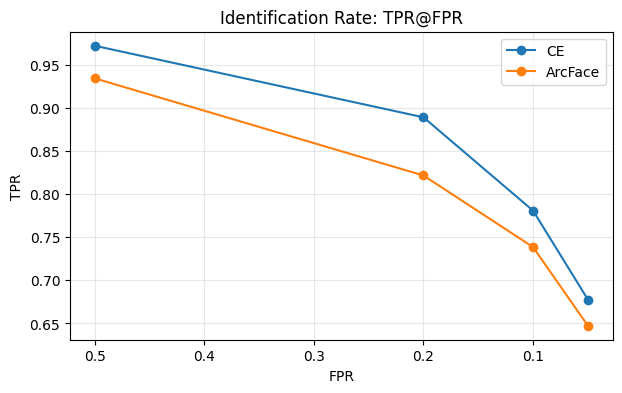

In [ ]:
plt.figure(figsize=(7,4))
fprs = [0.5, 0.2, 0.1, 0.05]
for name in rows:
    plt.plot(fprs, [rows[name][f] for f in fprs], marker="o", label=name)
plt.gca().invert_xaxis()
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Identification Rate: TPR@FPR")
plt.legend(); plt.grid(alpha=.3); plt.show()

## Итого

Реализовал метрику TPR@FPR по шаблону задания — проверочные тесты проходят. Посчитал её
на отложенных query/distractors.

| Модель | Бэкбон | TPR@FPR=0.5 | TPR@FPR=0.2 | TPR@FPR=0.1 | TPR@FPR=0.05 |
|---|---|---|---|---|---|
| CE | resnet18 | **0.972** | **0.889** | **0.781** | **0.678** |
| ArcFace | resnet50 | 0.934 | 0.821 | 0.739 | 0.647 |

**Результат противоположен ожидаемому.** CE выигрывает на всех четырёх порогах, причём разрыв
не сокращается при ужесточении FPR (при 0.05 он даже сохраняется: 0.678 против 0.647).
Это расходится и с теорией, и с моим собственным прогнозом в разделе 4.

Отдельно стоит отметить: CE обучался на `resnet18`, ArcFace — на `resnet50`, то есть
**более слабая по бэкбону модель обошла более сильную**. Обратная сторона того же факта —
сравнение двух лоссов здесь некорректно, потому что бэкбоны разные. Строго говоря, из этих
цифр нельзя заключить «CE лучше ArcFace»; можно заключить только, что в моей конкретной
конфигурации связка CE + resnet18 дала лучшее качество на незнакомых лицах, чем
ArcFace + resnet50 после 15 эпох.

**Почему так могло получиться.** ArcFace с отступом m=0.5 без прогрева требует заметно больше
эпох до сходимости: по логам обучения его loss на первой эпохе был вчетверо выше, чем у CE,
и обе модели к 15-й эпохе уже переобучились по train loss. Вероятно, ArcFace просто не успел
сформировать геометрию эмбеддингов, ради которой его и берут.

**Что нужно, чтобы сделать корректный вывод:** обучить обе модели на одном бэкбоне,
добавить ArcFace прогрев отступа и увеличить число эпох до выхода val-метрики на плато.
До этого момента честная формулировка — «в моём прогоне ArcFace не подтвердил ожидаемого
преимущества», а не «ArcFace хуже CE».

**Ценность метрики.** Отдельный вывод не про модели, а про измерение: val accuracy
и TPR@FPR дали противоположные ответы. Accuracy сказала, что ArcFace лучше (0.8021 против
0.7426), TPR@FPR — что хуже. Accuracy меряет классификацию знакомых личностей, TPR@FPR —
работу на незнакомых. Для распознавания лиц вторая метрика ближе к реальному сценарию,
и ориентироваться нужно на неё.